#   PERCOBAAN 1
resize dan grayscale

In [80]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rembg import remove
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

In [81]:
data = []
labels = []
file_name = []

dataset_path = "." 

target_folders = ["Brokoli", "Kembang Kol"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Brokoli', 'Kembang Kol'], dtype='<U11'), array([100, 100]))


## Data Preparation

### Difine Preprocessing

In [82]:
def removeBackground(img):
    if img is None:
        return None
        
    img_removed = remove(img) 
    img_removed_rgb = cv.cvtColor(img_removed, cv.COLOR_RGBA2RGB)
    return img_removed_rgb

In [83]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

In [84]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

### Preprocessing

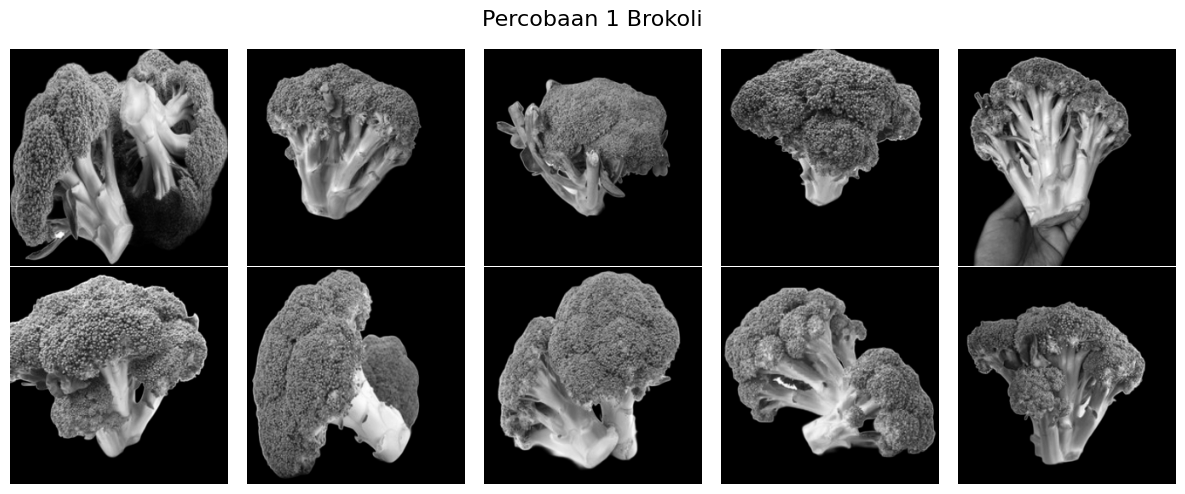

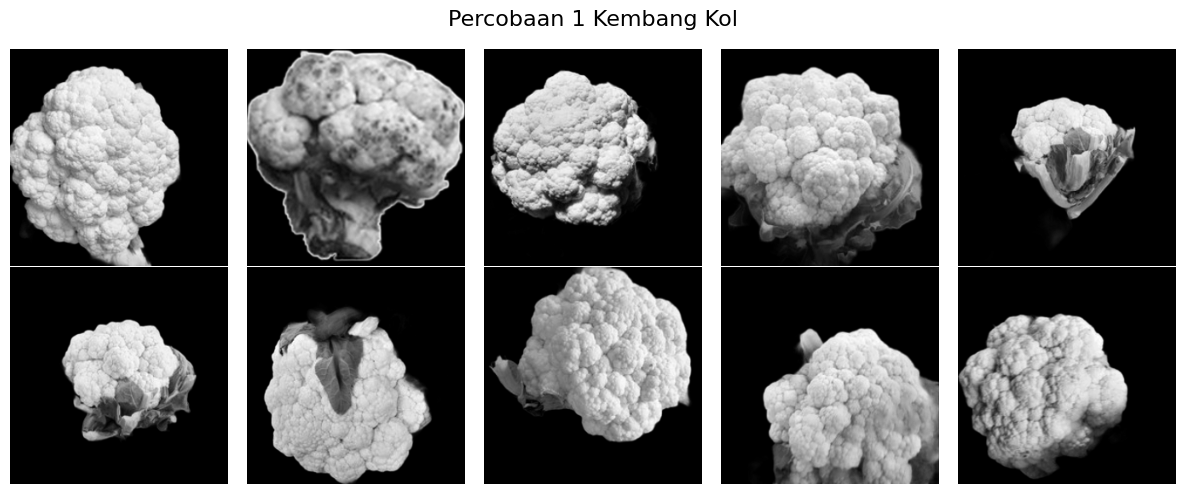

In [85]:
def percobaan1(img):
    img_no_bg = removeBackground(img)
    img_gray = grayscale(img_no_bg)
    img_resize = resize(img_gray, 256, 256)
    return img_resize

dataPreprocessed = [percobaan1(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Percobaan 1 {label}', fontsize=16)
    
    for k in range(10):
        row = k // 5
        col = k % 5
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

### Ekstraksi Fitur

In [86]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [87]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [88]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,329.574525,0.964880,0.249706,0.338260,10.785279,0.062353,7.270443,percobaan1
1,79.508946,0.979398,0.652128,0.693672,3.666176,0.425271,3.467013,percobaan1
2,94.466330,0.976604,0.666860,0.704346,3.882598,0.444702,3.351341,percobaan1
3,125.063235,0.956885,0.619162,0.653819,5.091789,0.383362,3.815256,percobaan1
4,120.196017,0.981360,0.514439,0.584933,5.040931,0.264648,4.775858,percobaan1
...,...,...,...,...,...,...,...,...
195,40.332920,0.994601,0.357198,0.517619,3.329733,0.127590,5.722925,percobaan1
196,107.554335,0.992945,0.530111,0.614294,4.295665,0.281018,4.461880,percobaan1
197,79.056970,0.992880,0.618923,0.675119,3.383287,0.383066,3.730091,percobaan1
198,85.223039,0.994371,0.571910,0.649134,3.446048,0.327081,3.969681,percobaan1


In [89]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Hasil Ekstraksi ke CSV

In [90]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [91]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,Brokoli,329.574525,448.143622,225.897151,489.471757,0.338260,0.328333,0.358975,0.320797,...,0.062294,0.060307,0.249706,0.244677,0.249587,0.245574,0.964880,0.952185,0.975920,0.947776
1,0002.jpg,Brokoli,79.508946,136.335040,70.261244,115.826836,0.693672,0.683122,0.708945,0.693554,...,0.425222,0.422031,0.652128,0.649462,0.652090,0.649639,0.979398,0.964751,0.981794,0.970053
2,0003.jpg,Brokoli,94.466330,133.575056,87.328002,163.025575,0.704346,0.697089,0.710342,0.694303,...,0.443993,0.439849,0.666860,0.664549,0.666328,0.663211,0.976604,0.966993,0.978371,0.959716
3,0004.jpg,Brokoli,125.063235,229.449212,152.837852,214.831972,0.653819,0.643268,0.654949,0.644135,...,0.382791,0.379665,0.619162,0.616015,0.618701,0.616170,0.956885,0.921060,0.947308,0.926089
4,0005.jpg,Brokoli,120.196017,164.717247,89.253202,194.567982,0.584933,0.573919,0.619643,0.576308,...,0.266382,0.263154,0.514439,0.511984,0.516122,0.512986,0.981360,0.974497,0.986163,0.969875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0096.jpg,Kembang Kol,40.332920,107.041030,80.613572,123.953018,0.517619,0.472968,0.491246,0.462912,...,0.124676,0.123286,0.357198,0.351425,0.353095,0.351121,0.994601,0.985680,0.989213,0.983418
196,0097.jpg,Kembang Kol,107.554335,192.743975,112.426103,208.289596,0.614294,0.599193,0.627335,0.593760,...,0.280376,0.276732,0.530111,0.525973,0.529505,0.526053,0.992945,0.987372,0.992625,0.986353
197,0098.jpg,Kembang Kol,79.056970,128.495087,72.375061,144.418562,0.675119,0.669602,0.683808,0.658471,...,0.381830,0.379625,0.618923,0.615965,0.617924,0.616137,0.992880,0.988449,0.993481,0.987017
198,0099.jpg,Kembang Kol,85.223039,149.798324,86.583517,158.615363,0.649134,0.636458,0.653360,0.627610,...,0.327034,0.323842,0.571910,0.568668,0.571869,0.569071,0.994371,0.990118,0.994281,0.989537


## Feature Selection

### Correlation

Berdasarkan hasil pengujian korelasi terhadap 28 fitur GLCM awal, ditemukan tingkat multikolinearitas yang sangat tinggi antar-fitur properti tekstur. Dengan menerapkan threshold korelasi sebesar 0.85, sistem berhasil mereduksi dimensi data secara signifikan hingga menyisakan 3 fitur independen terbaik, yaitu Contrast0, Homogeneity0, dan ASM0. Meskipun eliminasi data redundan ini menyebabkan penurunan akurasi model Random Forest dari 92.50% menjadi 82.50%, penggunaan 3 fitur hasil seleksi ini dinilai jauh lebih efisien dalam memangkas waktu komputasi training model secara masif dengan tetap mempertahankan performa klasifikasi objek brokoli dan kembang kol yang kuat.

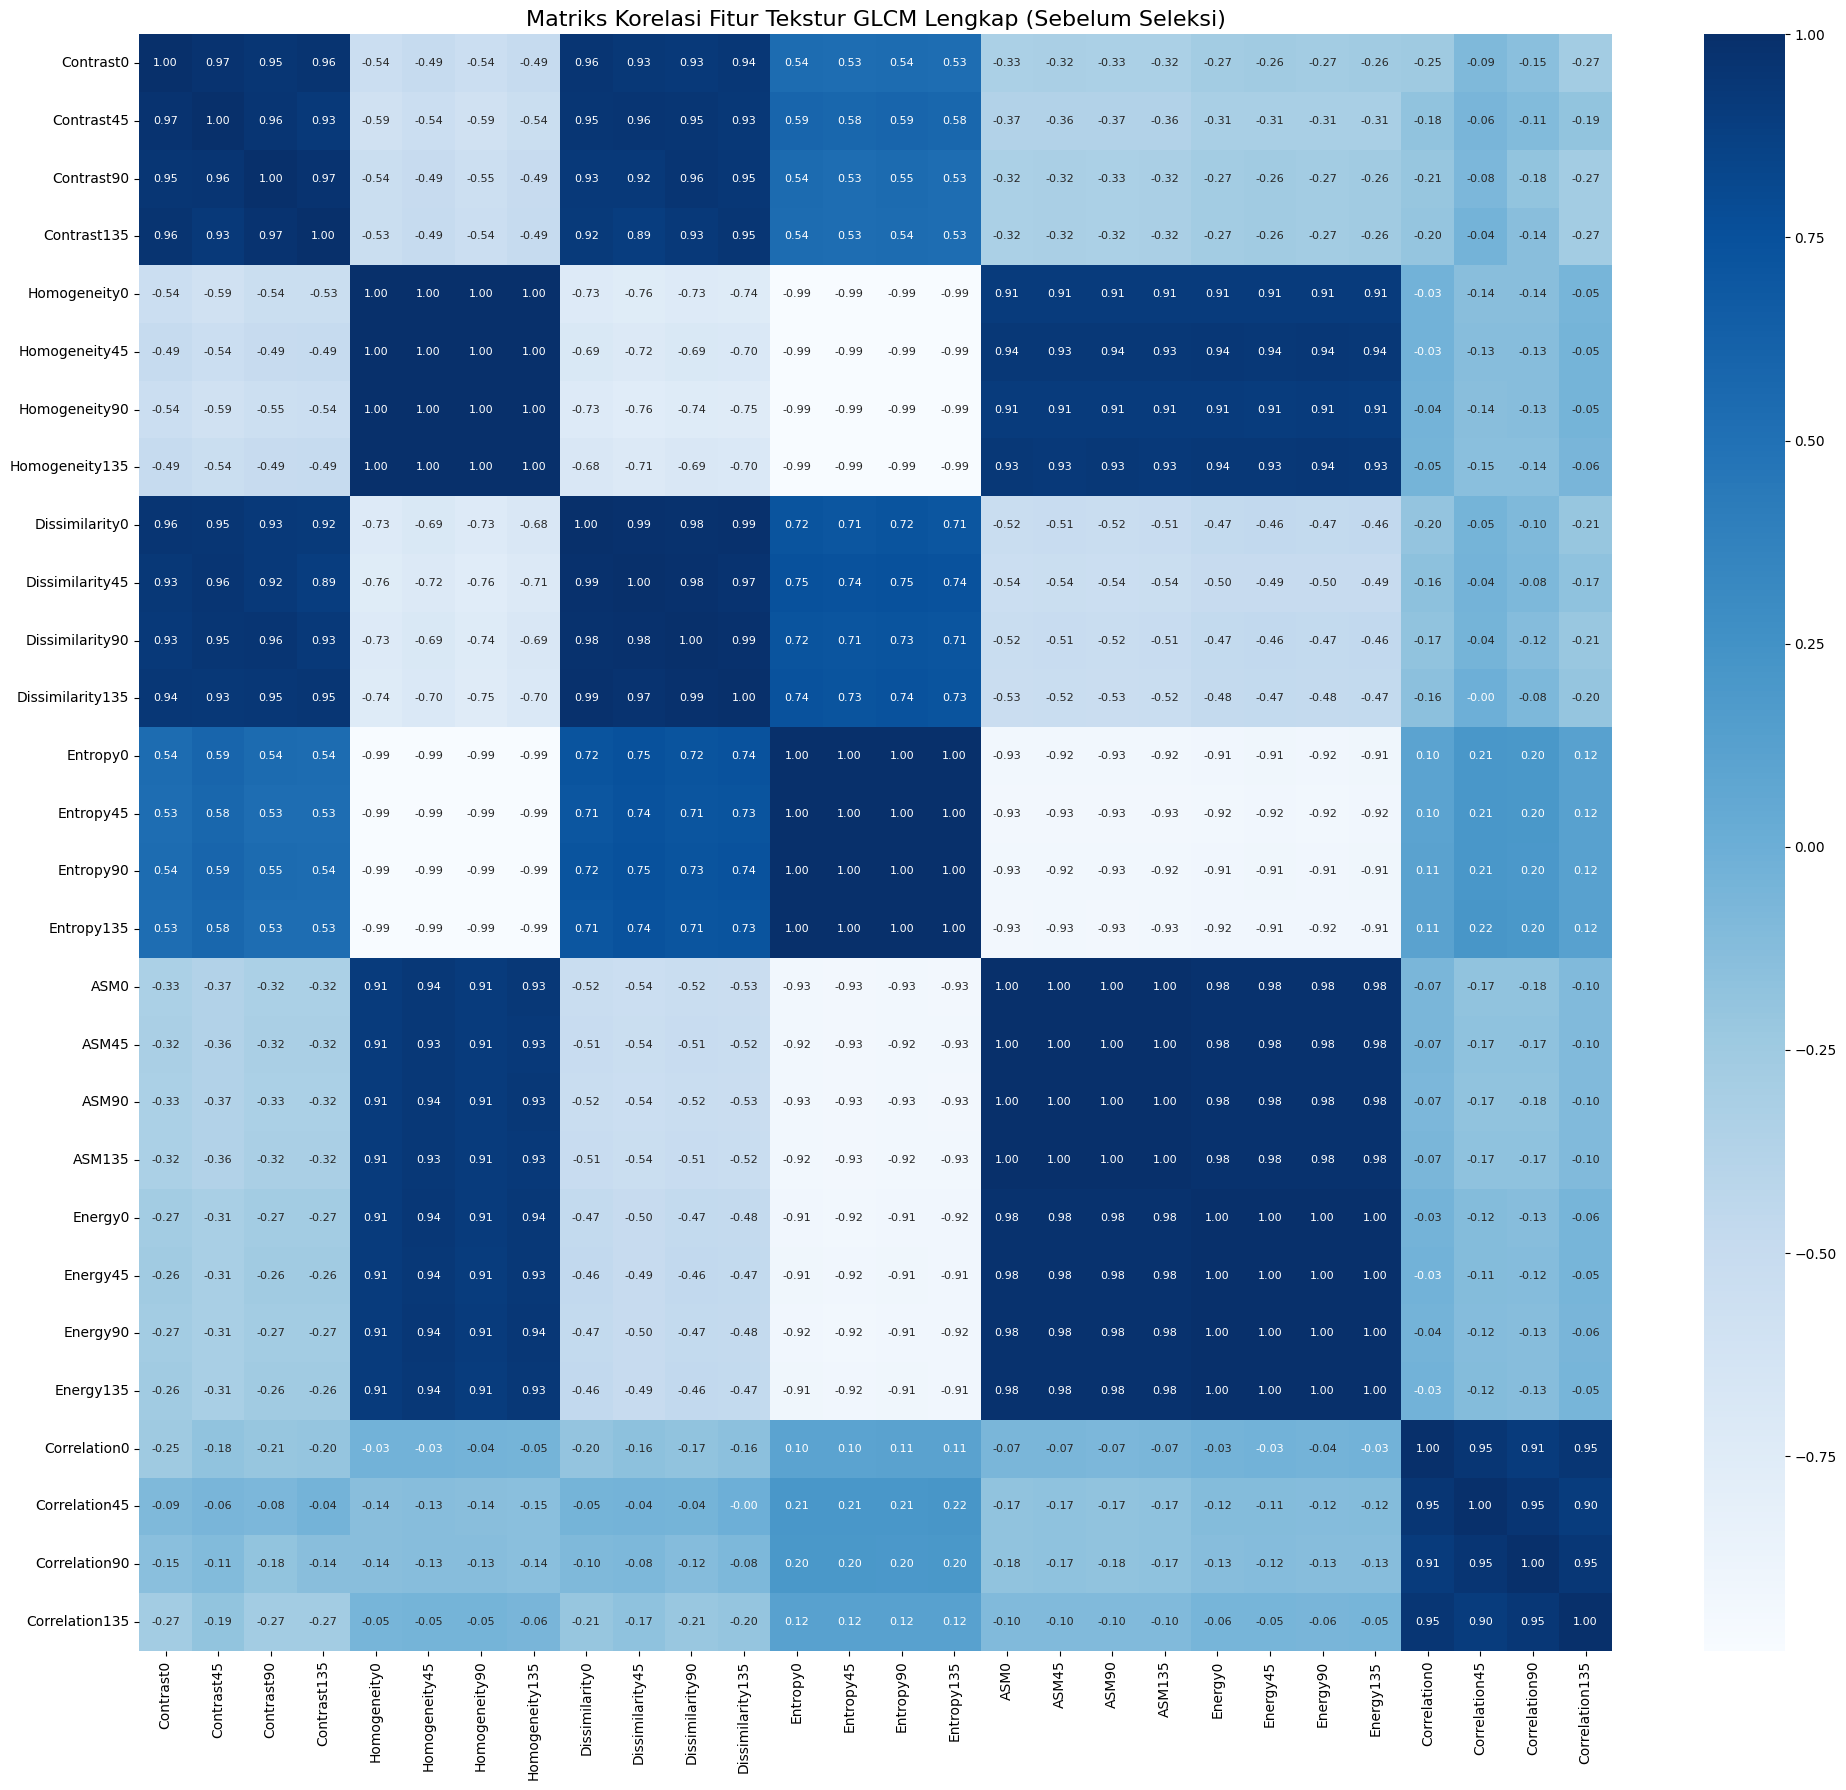

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 3 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'Correlation0']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 85.00%
Akurasi SETELAH Seleksi Korelasi (3 fitur) : 82.50%


In [92]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap (Sebelum Seleksi)", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

### Spliting Data

In [93]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


### Feature Normalization

In [94]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode ini digunakan untuk normalisasi mean-std (Standardisasi atau Z-score normalization) pada fitur-fitur training (X_train) dan testing set (X_test). Normalisasi ini dilakukan dengan mengurangi setiap nilai fitur dengan rata-rata training set (X_train.mean()) dan membaginya dengan standar deviasi training set (X_train.std()). Pentingnya metode ini adalah bahwa rata-rata dan standar deviasi hanya dihitung dari X_train dan kemudian diterapkan ke X_test, sebuah praktik yang mencegah data leakage dan memastikan integritas pengujian model.

## Modeling

### Define Model

In [104]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=4, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [105]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.93      0.99      0.96        79
 Kembang Kol       0.99      0.93      0.96        81

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160

[[78  1]
 [ 6 75]]
Accuracy: 0.95625

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.80      0.95      0.87        21
 Kembang Kol       0.93      0.74      0.82        19

    accuracy                           0.85        40
   macro avg       0.87      0.84      0.85        40
weighted avg       0.86      0.85      0.85        40

[[20  1]
 [ 5 14]]
Accuracy: 0.85


### Train SVM Classifier

In [108]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.91      0.94      0.93        79
 Kembang Kol       0.94      0.91      0.93        81

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160

[[74  5]
 [ 7 74]]
Accuracy: 0.925

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.79      0.90      0.84        21
 Kembang Kol       0.88      0.74      0.80        19

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40

[[19  2]
 [ 5 14]]
Accuracy: 0.825


### Train KNN Classifier

In [109]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.91      0.95      0.93        79
 Kembang Kol       0.95      0.91      0.93        81

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160

[[75  4]
 [ 7 74]]
Accuracy: 0.93125

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.77      0.81      0.79        21
 Kembang Kol       0.78      0.74      0.76        19

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40

[[17  4]
 [ 5 14]]
Accuracy: 0.775


### Evaluasi Dengan Confussion Matrix

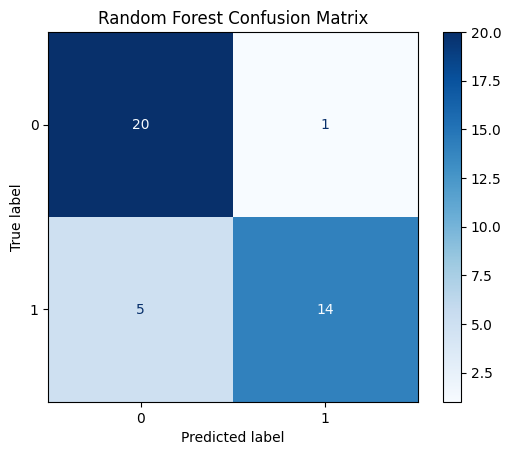

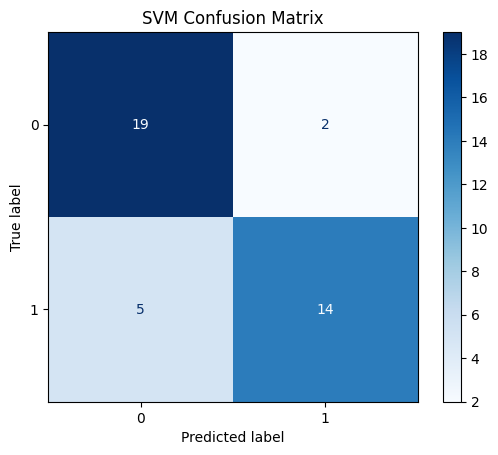

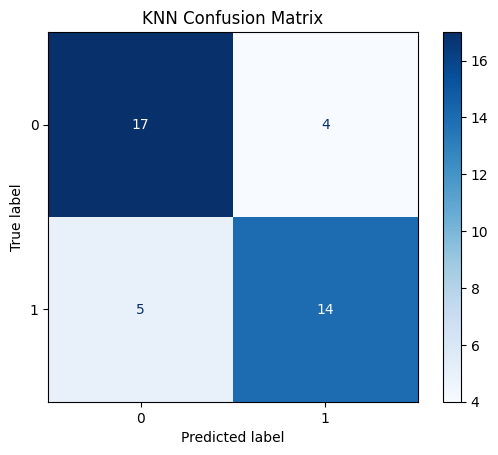

In [110]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")